# 08. Temporal Stacking
Process a time-series stack of multiple aligned GeoTIFFs into a single reduced output.

In [1]:
import curaster
import glob
import os
import matplotlib.pyplot as plt

# Find all files in the stack_S directory
stack_dir = "../build/benchmark_data/stack_S"
files = sorted(glob.glob(os.path.join(stack_dir, "*.tif")))
print(f"Found {len(files)} scenes in stack.")

Found 5 scenes in stack.


## Apply Pre-processing and Temporal Reduction
We use `.open_stack()`, apply NDVI to *every* scene in the stack using `StackChain.algebra()`, and then compute the temporal mean.

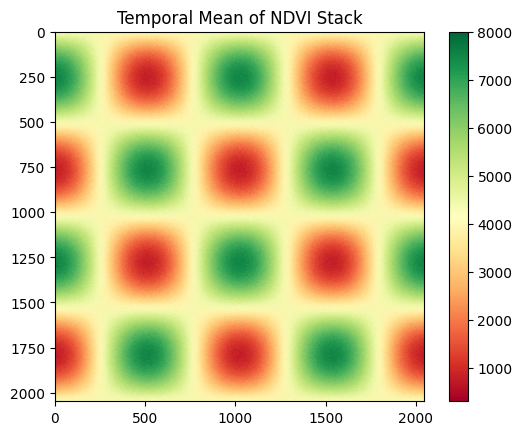

CPU times: user 1.06 s, sys: 547 ms, total: 1.61 s
Wall time: 1.68 s


In [2]:
%%time
if len(files) > 0:
    # Open stack
    stack = curaster.open_stack(files)
    
    # Pre-process all scenes (NDVI)
    stack = stack.algebra("(B5 - B4) / (B5 + B4)").reproject("EPSG:4326")
    result = stack.temporal("mean").to_memory()
    
    # Plot
    arr = result.data()
    plt.imshow(arr, cmap="RdYlGn")
    plt.title("Temporal Mean of NDVI Stack")
    plt.colorbar()
    plt.show()
else:
    print("No files found.")